# Setup


In [1]:
%pip install ipywidgets
%pip install duckdb
%pip install matplotlib
%pip install seaborn
%pip install scipy
%matplotlib inline

import sys
sys.path.append('../scripts')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import duckdb

In [3]:
gpt5mini_features = duckdb.read_csv("features/v1.3/stackoverflow_dba_sqlstorm.csv.gz")
gpt5mini_features_with_rewrite = duckdb.read_csv("features/v1.3/stackoverflow_dba_sqlstorm_with_rewrite.csv.gz")
gpt5mini_queries = duckdb.read_csv("queries/v1.3/stackoverflow.csv.gz")
gpt5nano_features = duckdb.read_csv("features/v1.4/stackoverflow_dba_sqlstorm.csv.gz")
gpt5nano_features_with_rewrite = duckdb.read_csv("features/v1.4/stackoverflow_dba_sqlstorm_with_rewrite.csv.gz")
gpt5nano_queries = duckdb.read_csv("queries/v1.4/stackoverflow.csv.gz")
llm = duckdb.read_csv("llm.csv")
reasoning_mapping = duckdb.query("""select * from values ('minimal', 3), ('low', 2), ('medium', 1), ('high', 0) as t(reasoning, level)""")

In [4]:
gpt5mini_queries_cost = duckdb.query("""select *, sum(output_tokens*output + input_tokens*input) over (partition by reasoning) / 1000000 as cost from gpt5mini_queries join llm using (model)""")
gpt5nano_queries_cost = duckdb.query("""select *, sum(output_tokens*output + input_tokens*input) over (partition by reasoning) / 1000000 as cost from gpt5nano_queries join llm using (model)""")

gpt5mini_queries_cost.show()

┌─────────┬────────────┬─────────┬─────────────┬───────────┬──────────────┬───────────────┬───────┬────────────┬───────┬───────┬─────────┬────────┬────────┬──────────┐
│  query  │   model    │ prompt  │ temperature │ reasoning │ input_tokens │ output_tokens │ bytes │ characters │ words │ lines │ vendor  │ input  │ output │   cost   │
│ varchar │  varchar   │ varchar │   double    │  varchar  │    int64     │     int64     │ int64 │   int64    │ int64 │ int64 │ varchar │ double │ double │  double  │
├─────────┼────────────┼─────────┼─────────────┼───────────┼──────────────┼───────────────┼───────┼────────────┼───────┼───────┼─────────┼────────┼────────┼──────────┤
│ 201.sql │ gpt-5-mini │ p1      │         1.0 │ medium    │         2026 │          4041 │  5762 │       5232 │   703 │   155 │ OpenAI  │  0.125 │    1.0 │ 0.491946 │
│ 277.sql │ gpt-5-mini │ p1      │         1.0 │ medium    │         2026 │          3738 │  9221 │       8219 │   993 │   202 │ OpenAI  │  0.125 │    1.0 │ 0.4

In [5]:
gpt5mini = duckdb.query(
    """select reasoning, level, count(*), avg(ops), min(cost) / count(*) * 1000, max(cost) * 10 as cost from gpt5mini_features join gpt5mini_queries_cost using (query) join reasoning_mapping using (reasoning) group by reasoning, level order by level asc""")
gpt5nano = duckdb.query(
    """select reasoning, level, count(*), avg(ops), min(cost) / count(*) * 1000, max(cost) * 10 as cost from gpt5nano_features join gpt5nano_queries_cost using (query) join reasoning_mapping using (reasoning) group by reasoning, level order by level asc""")
gpt5mini.show()
gpt5nano.show()

┌───────────┬───────┬──────────────┬────────────────────┬───────────────────────────────────────┬────────────────────┐
│ reasoning │ level │ count_star() │      avg(ops)      │ ((min("cost") / count_star()) * 1000) │        cost        │
│  varchar  │ int32 │    int64     │       double       │                double                 │       double       │
├───────────┼───────┼──────────────┼────────────────────┼───────────────────────────────────────┼────────────────────┤
│ high      │     0 │           10 │               57.5 │                              167.4728 │           16.74728 │
│ medium    │     1 │            9 │  43.55555555555556 │                    54.660666666666664 │            4.91946 │
│ low       │     2 │           10 │               32.8 │                    27.814999999999998 │ 2.7815000000000003 │
│ minimal   │     3 │            3 │ 51.666666666666664 │                     83.83699999999999 │            2.51511 │
└───────────┴───────┴──────────────┴────────────

In [6]:
gpt5mini_with_rewrite = duckdb.query(
    """select reasoning, level, count(*), avg(ops), min(cost) / count(*) * 1000, max(cost) * 10 as cost from gpt5mini_features_with_rewrite join gpt5mini_queries_cost using (query) join reasoning_mapping using (reasoning) group by reasoning, level order by level asc""")
gpt5nano_with_rewrite = duckdb.query(
    """select reasoning, level, count(*), avg(ops), min(cost) / count(*) * 1000, max(cost) * 10 as cost from gpt5nano_features_with_rewrite join gpt5nano_queries_cost using (query) join reasoning_mapping using (reasoning) group by reasoning, level order by level asc""")
gpt5mini_with_rewrite.show()
gpt5nano_with_rewrite.show()

┌───────────┬───────┬──────────────┬────────────────────┬───────────────────────────────────────┬────────────────────┐
│ reasoning │ level │ count_star() │      avg(ops)      │ ((min("cost") / count_star()) * 1000) │        cost        │
│  varchar  │ int32 │    int64     │       double       │                double                 │       double       │
├───────────┼───────┼──────────────┼────────────────────┼───────────────────────────────────────┼────────────────────┤
│ high      │     0 │           18 │  61.27777777777778 │                     93.04044444444445 │           16.74728 │
│ medium    │     1 │           20 │               48.6 │                               24.5973 │            4.91946 │
│ low       │     2 │           23 │  39.73913043478261 │                    12.093478260869565 │ 2.7815000000000003 │
│ minimal   │     3 │           14 │ 48.642857142857146 │                    17.965071428571427 │            2.51511 │
└───────────┴───────┴──────────────┴────────────

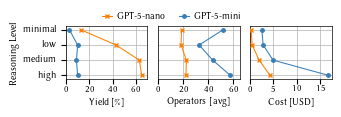

In [9]:
from plot.linestyle import Linestyle
from plot.marker import Marker
from plot.color import Color
from plot.location import Location
from plot.formatter import Decorator, Grid, LabelFormatter, NumberFormatter, Scale
from plot.lineplot import LinePlot
from plot.frame import Format, GridFrame, Frame, cm2inch, latexify
from matplotlib.patches import Rectangle

mini = gpt5mini.fetchall()
nano = gpt5nano.fetchall()
reasoning = [row[1] for row in mini]
labels = [row[0] for row in mini]

latexify(hyperref=False, increase_font=-1)
frame = GridFrame(width=3.3, height=0.9, n_rows=1, n_columns=3)
plot = LinePlot(frame[0, 0])
plot.format_axes(yformatter=LabelFormatter(ticklabels=labels, padding=-0.25, grid=Grid.MAJOR, label="Reasoning Level"),
                 xformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=70, ticks=[0, 20, 40, 60], label="Yield [\\%]"))
h1 = plot.plot(y=reasoning, x=[row[2] for row in nano], color=Color.ORANGE, marker=Marker.CROSS)
h2 = plot.plot(y=reasoning, x=[row[2] for row in mini], color=Color.BLUE, marker=Marker.CIRCLE)

plot = LinePlot(frame[0, 1])
plot.format_axes(yformatter=LabelFormatter(ticklabels=labels, padding=-0.25, grid=Grid.MAJOR, label="Reasoning Level", decorator=Decorator.NONE),
                 xformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=65, ticks=[0, 20, 40, 60], label="Operators [avg]"))
plot.plot(y=reasoning, x=[row[3] for row in nano], color=Color.ORANGE, marker=Marker.CROSS)
plot.plot(y=reasoning, x=[row[3] for row in mini], color=Color.BLUE, marker=Marker.CIRCLE)

plot = LinePlot(frame[0, 2])
plot.format_axes(yformatter=LabelFormatter(ticklabels=labels, padding=-0.25, grid=Grid.MAJOR, label="Reasoning Level", decorator=Decorator.NONE),
                 xformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=17.5, ticks=[0, 5, 10, 15], label="Cost [USD]"))
plot.plot(y=reasoning, x=[row[5] for row in nano], color=Color.ORANGE, marker=Marker.CROSS)
plot.plot(y=reasoning, x=[row[5] for row in mini], color=Color.BLUE, marker=Marker.CIRCLE)

frame.legend([h1, h2], ["GPT-5-nano", "GPT-5-mini"], bbox_to_anchor=(0.5, 1.05), location=Location.CENTER, columns=3)
frame.save(os.path.join("pdf/reasoning"), format=Format.PDF)